<a href="https://colab.research.google.com/github/suyogy1-bot/Matplotlib_Seaborn/blob/main/EDA_Gapminder.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# EDA Project: Gapminder World Development Dataset 🌍

**Dataset:** The famous **Gapminder** dataset — real-world data on
**population, life expectancy, and GDP per capita** for 142 countries,
tracked every 5 years from 1952 to 2007.

> This is **not** a built-in Seaborn dataset — it is downloaded fresh from a public
> GitHub CSV file (maintained by Plotly), just like downloading a dataset from Kaggle.

**Libraries used:** NumPy, Pandas, Matplotlib, Seaborn

### Roadmap
1. Import libraries
2. Download & load the dataset
3. Basic exploration
4. Missing values check
5. Filter to the latest year (2007) for country-level comparison
6. Univariate analysis — numeric (Histogram + KDE)
7. Univariate analysis — categorical (Count plot)
8. Bivariate analysis — Scatter plot
9. Bivariate analysis — Joint plot
10. Categorical vs Numeric — Bar plot, Box plot, Violin plot
11. Multivariate — Pair plot
12. Correlation heatmap
13. Trend over time — Line plot
14. Conclusions & Exercises


## Step 1: Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Step 2: Download & Load the Dataset

We download the CSV directly from a public GitHub link using `pandas.read_csv()`.

**Columns:**
- `country` : Country name
- `year` : Year of record (every 5 years, 1952–2007)
- `pop` : Population
- `continent` : Continent
- `lifeExp` : Life expectancy (years)
- `gdpPercap` : GDP per capita ($)


In [3]:
url = "https://raw.githubusercontent.com/plotly/datasets/master/gapminderDataFiveYear.csv"
df = pd.read_csv(url)

In [4]:
df.head()

,country,year,pop,continent,lifeExp,gdpPercap
0,Afghanistan,1952,8425333.0,Asia,28.801,779.445314
1,Afghanistan,1957,9240934.0,Asia,30.332,820.853030
2,Afghanistan,1962,10267083.0,Asia,31.997,853.100710
3,Afghanistan,1967,11537966.0,Asia,34.020,836.197138
4,Afghanistan,1972,13079460.0,Asia,36.088,739.981106


## Step 3: Basic Exploration

In [5]:
#1. Top 5 rows
df.head()

,country,year,pop,continent,lifeExp,gdpPercap
0,Afghanistan,1952,8425333.0,Asia,28.801,779.445314
1,Afghanistan,1957,9240934.0,Asia,30.332,820.853030
2,Afghanistan,1962,10267083.0,Asia,31.997,853.100710
3,Afghanistan,1967,11537966.0,Asia,34.020,836.197138
4,Afghanistan,1972,13079460.0,Asia,36.088,739.981106


In [6]:
#2. Information about the data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1704 entries, 0 to 1703
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   country    1704 non-null   object 
 1   year       1704 non-null   int64  
 2   pop        1704 non-null   float64
 3   continent  1704 non-null   object 
 4   lifeExp    1704 non-null   float64
 5   gdpPercap  1704 non-null   float64
dtypes: float64(3), int64(1), object(2)
memory usage: 80.0+ KB


In [7]:
#3. What Columns we have?
df.columns.tolist()

['country', 'year', 'pop', 'continent', 'lifeExp', 'gdpPercap']

## Step 4: Missing Values Check

In [8]:
df.isnull().sum()

,0
country,0
year,0
pop,0
continent,0
lifeExp,0
gdpPercap,0


In [9]:
# Check duplicates

df.duplicated().sum()

np.int64(0)

## Step 5: Filter to the Latest Year (2007)

The full dataset has **multiple rows per country** (one for each year).
For most of our plots, we want **one row per country**, so we filter to the most recent year: 2007.
This gives us a clean snapshot of the world in 2007 (142 countries).


In [10]:
df[df['year'] == 2007]

,country,year,pop,continent,lifeExp,gdpPercap
11,Afghanistan,2007,31889923.0,Asia,43.828,974.580338
23,Albania,2007,3600523.0,Europe,76.423,5937.029526
35,Algeria,2007,33333216.0,Africa,72.301,6223.367465
47,Angola,2007,12420476.0,Africa,42.731,4797.231267
59,Argentina,2007,40301927.0,Americas,75.320,12779.379640
...,...,...,...,...,...,...
1655,Vietnam,2007,85262356.0,Asia,74.249,2441.576404
1667,West Bank and Gaza,2007,4018332.0,Asia,73.422,3025.349798
1679,"Yemen, Rep.",2007,22211743.0,Asia,62.698,2280.769906
1691,Zambia,2007,11746035.0,Africa,42.384,1271.211593


In [11]:
df_2007 = df[df['year'] == 2007].reset_index(drop=True)

In [12]:
df_2007

,country,year,pop,continent,lifeExp,gdpPercap
0,Afghanistan,2007,31889923.0,Asia,43.828,974.580338
1,Albania,2007,3600523.0,Europe,76.423,5937.029526
2,Algeria,2007,33333216.0,Africa,72.301,6223.367465
3,Angola,2007,12420476.0,Africa,42.731,4797.231267
4,Argentina,2007,40301927.0,Americas,75.320,12779.379640
...,...,...,...,...,...,...
137,Vietnam,2007,85262356.0,Asia,74.249,2441.576404
138,West Bank and Gaza,2007,4018332.0,Asia,73.422,3025.349798
139,"Yemen, Rep.",2007,22211743.0,Asia,62.698,2280.769906
140,Zambia,2007,11746035.0,Africa,42.384,1271.211593


## Step 6: Univariate Analysis — Numeric Columns

### Histogram + KDE


In [13]:
a = df.corr(numeric_only=True)
a

,year,pop,lifeExp,gdpPercap
year,1.000000,0.082308,0.435611,0.227318
pop,0.082308,1.000000,0.064955,-0.025600
lifeExp,0.435611,0.064955,1.000000,0.583706
gdpPercap,0.227318,-0.025600,0.583706,1.000000


<Axes: xlabel='lifeExp', ylabel='Density'>

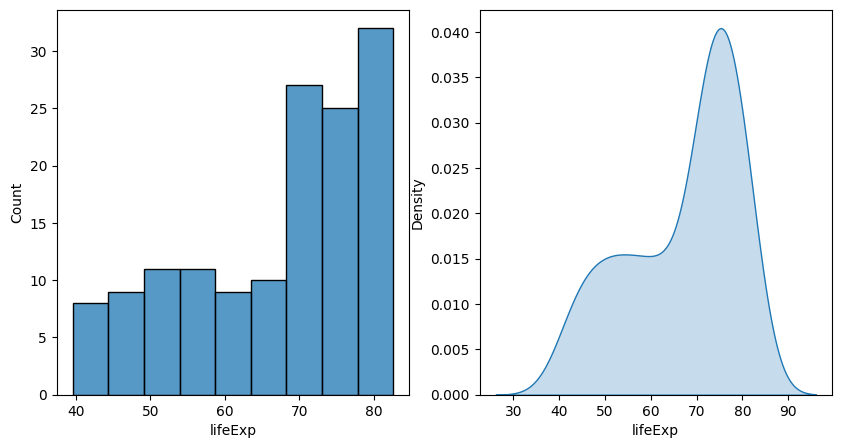

In [14]:
a, b = plt.subplots(1,2, figsize=(10, 5))

sns.histplot(data=df_2007, x="lifeExp", ax=b[0])
sns.kdeplot(data=df_2007, x="lifeExp", ax=b[1], fill=True)

## Step 7: Univariate Analysis — Categorical Column

### Count Plot
How many countries do we have per continent?


<Axes: xlabel='continent', ylabel='count'>

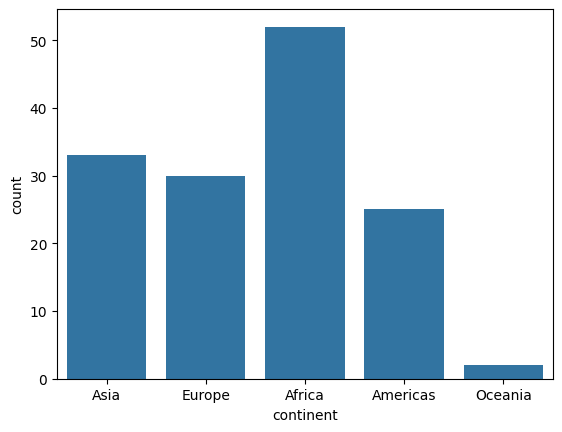

In [15]:
sns.countplot(data=df_2007, x="continent")

## Step 8: Bivariate Analysis — Scatter Plot

Does a richer country (higher GDP per capita) also have higher life expectancy?


<Axes: xlabel='gdpPercap', ylabel='lifeExp'>

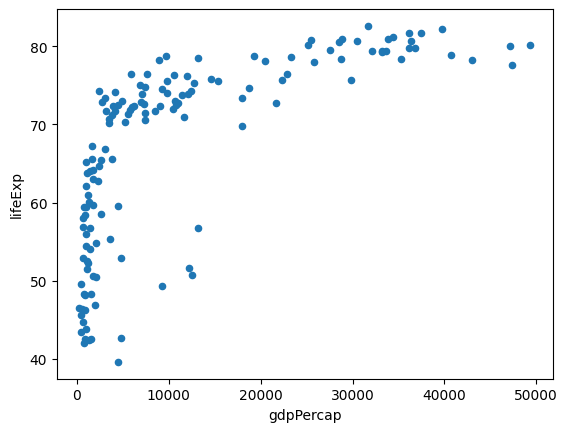

In [16]:
df_2007.plot.scatter(x="gdpPercap", y="lifeExp")

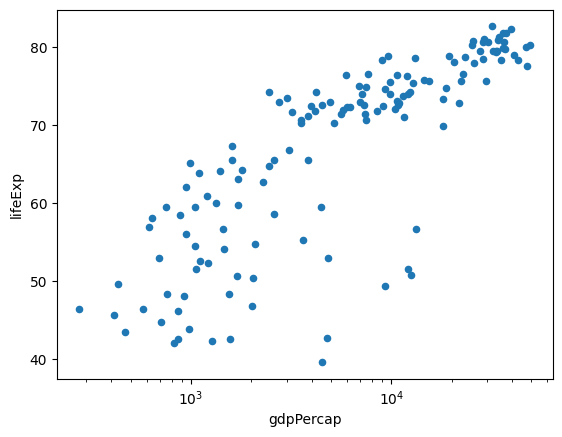

In [18]:
ax = df_2007.plot.scatter(x="gdpPercap", y="lifeExp")
ax.set_xscale("log")

Text(0.5, 1.0, 'GDP per capita vs Life Expectancy (2007)')

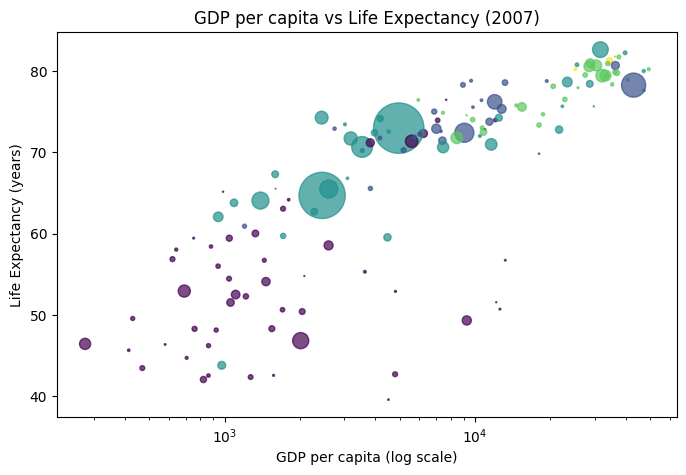

In [19]:
plt.figure(figsize=(8, 5))
scatter = plt.scatter(
    df_2007["gdpPercap"],
    df_2007["lifeExp"],
    c=df_2007["continent"].astype("category").cat.codes,
    s=df_2007["pop"] / 1e6,  # scale population to reasonable marker sizes
    alpha=0.7
)
plt.xscale("log")
plt.xlabel("GDP per capita (log scale)")
plt.ylabel("Life Expectancy (years)")
plt.title("GDP per capita vs Life Expectancy (2007)")

There is a clear positive association between GDP per capita and life expectancy.

- The curve flattens at high GDP per capita, suggesting diminishing returns of income on life expectancy.

- Low-income countries show larger variation in life expectancy, indicating other factors (war, health systems, inequality) matter a lot at low income levels.

## Step 9: Joint Plot

A joint plot combines a scatter/KDE plot with the individual distributions of both variables.


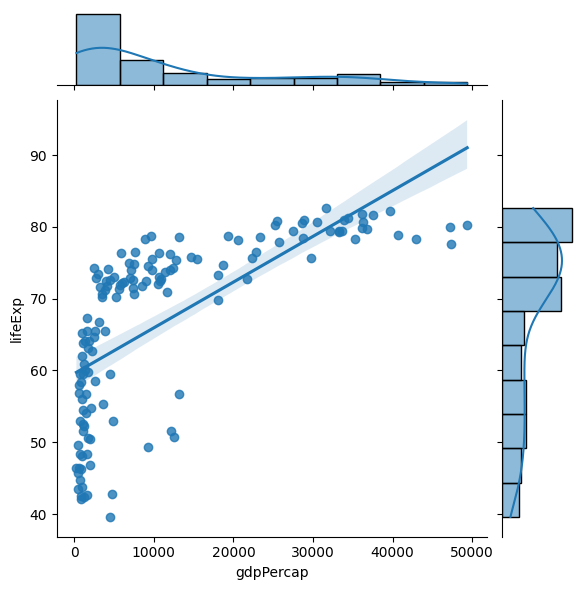

In [22]:
# life expectancy with gdpPercap

sns.jointplot(data=df_2007, x="gdpPercap", y="lifeExp", kind="reg")
plt.show()

## Step 10: Categorical vs Numeric — Bar, Box & Violin Plots


In [23]:
# Continent vs Life expectancy
df_2007['continent'].unique()

array(['Asia', 'Europe', 'Africa', 'Americas', 'Oceania'], dtype=object)

<Axes: xlabel='continent', ylabel='lifeExp'>

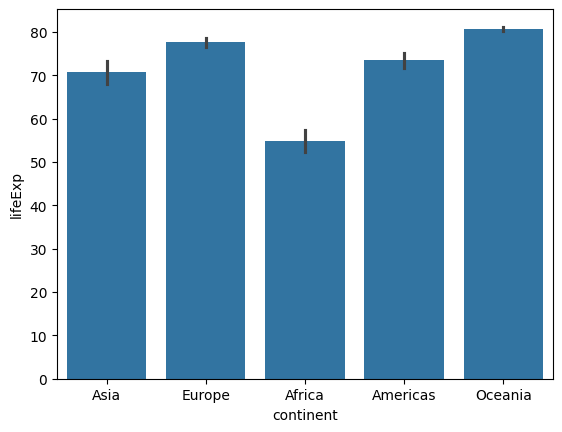

In [24]:
sns.barplot(data=df_2007, x="continent", y="lifeExp")

<Axes: xlabel='continent', ylabel='lifeExp'>

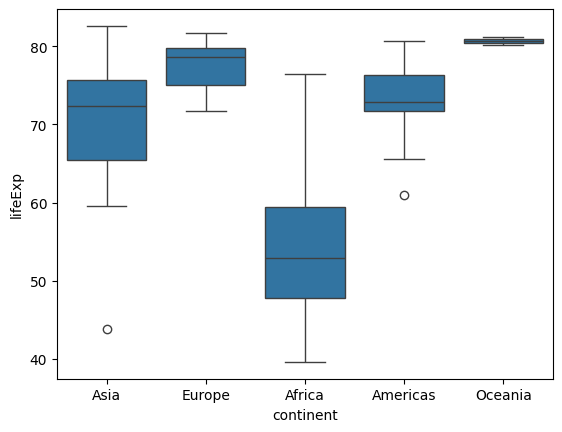

In [25]:
sns.boxplot(data=df_2007, x="continent", y="lifeExp")

<Axes: xlabel='continent', ylabel='lifeExp'>

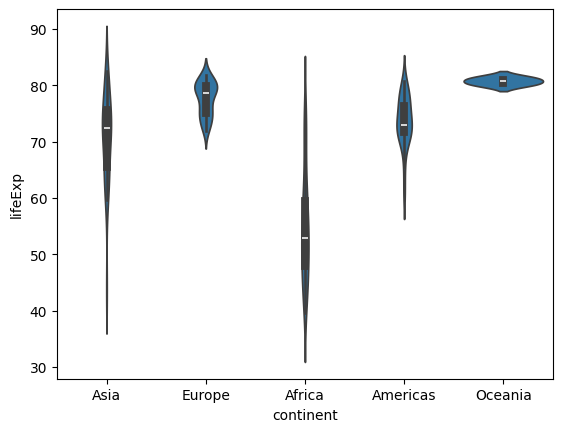

In [26]:
sns.violinplot(data=df_2007, x="continent", y="lifeExp")

**point:**
- **Bar plot** = average value per category.
- **Box plot** = spread, median, and outliers.
- **Violin plot** = full distribution shape per category.


## Outlier Detection

In [37]:
# Identify how we can use median line in box plot, like how it show skewness

In [39]:
# Q1. Quartile 1 -> 25%
# Q3. Quartile 3 -> 75%

# IQR = Q3 - Q1
# lower_bound = Q1 - 1.5 * IQR (Inter Quartile Range)
# upper_bound = Q3 + 1.5 * IQR

## Step 11: Multivariate Analysis — Pair Plot


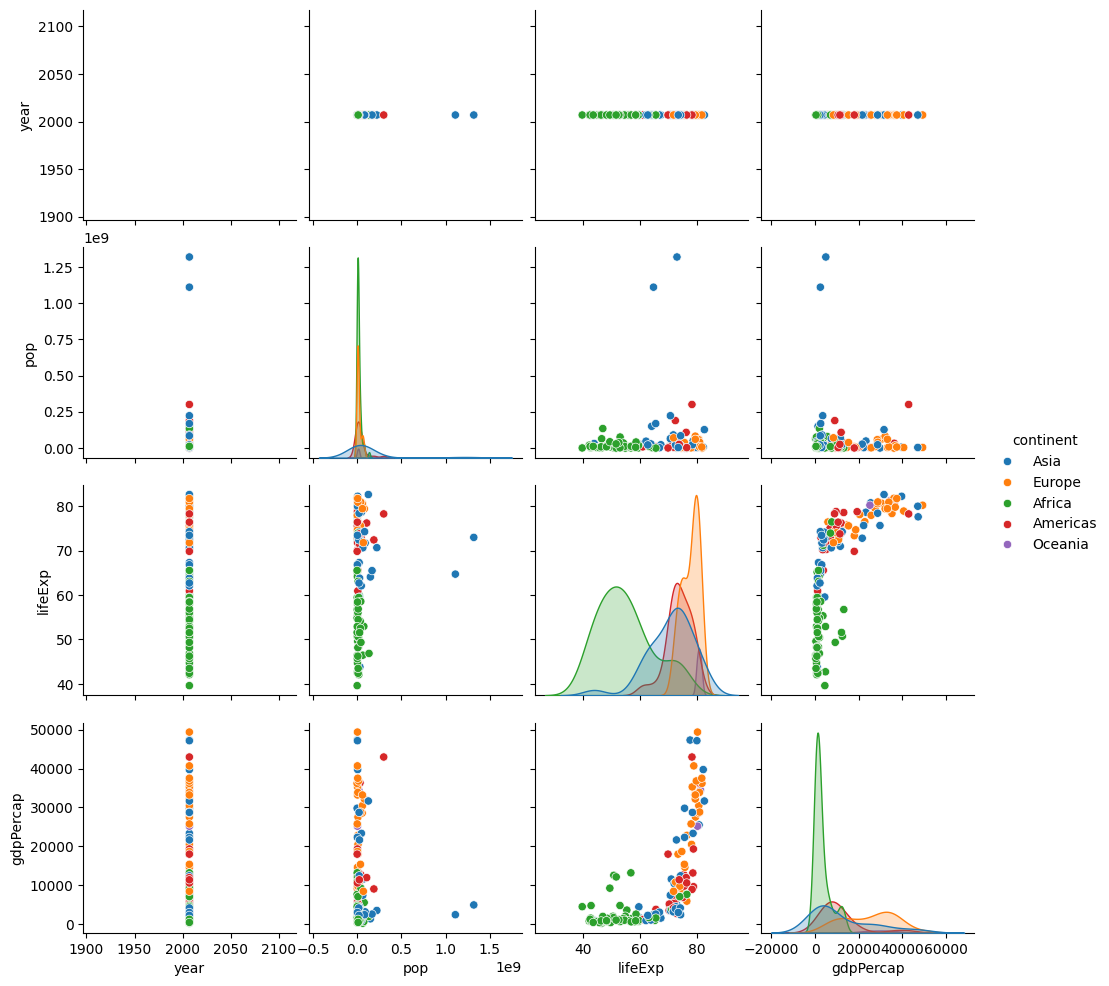

In [27]:
sns.pairplot(data=df_2007, hue="continent")

In [28]:
# When using continuous variable, pair plot use scatter plot
# When using integer, pair plot use kde plot

## Step 12: Correlation Heatmap

<Axes: >

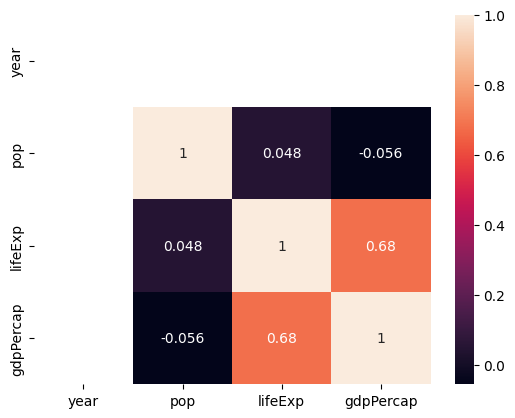

In [29]:
sns.heatmap(df_2007.corr(numeric_only=True), annot=True)

## Step 13: Trend Over Time — Line Plot

Now let's use the **full dataset** (all years) to see how life expectancy changed
over time for a few selected countries.


<Axes: xlabel='year', ylabel='lifeExp'>

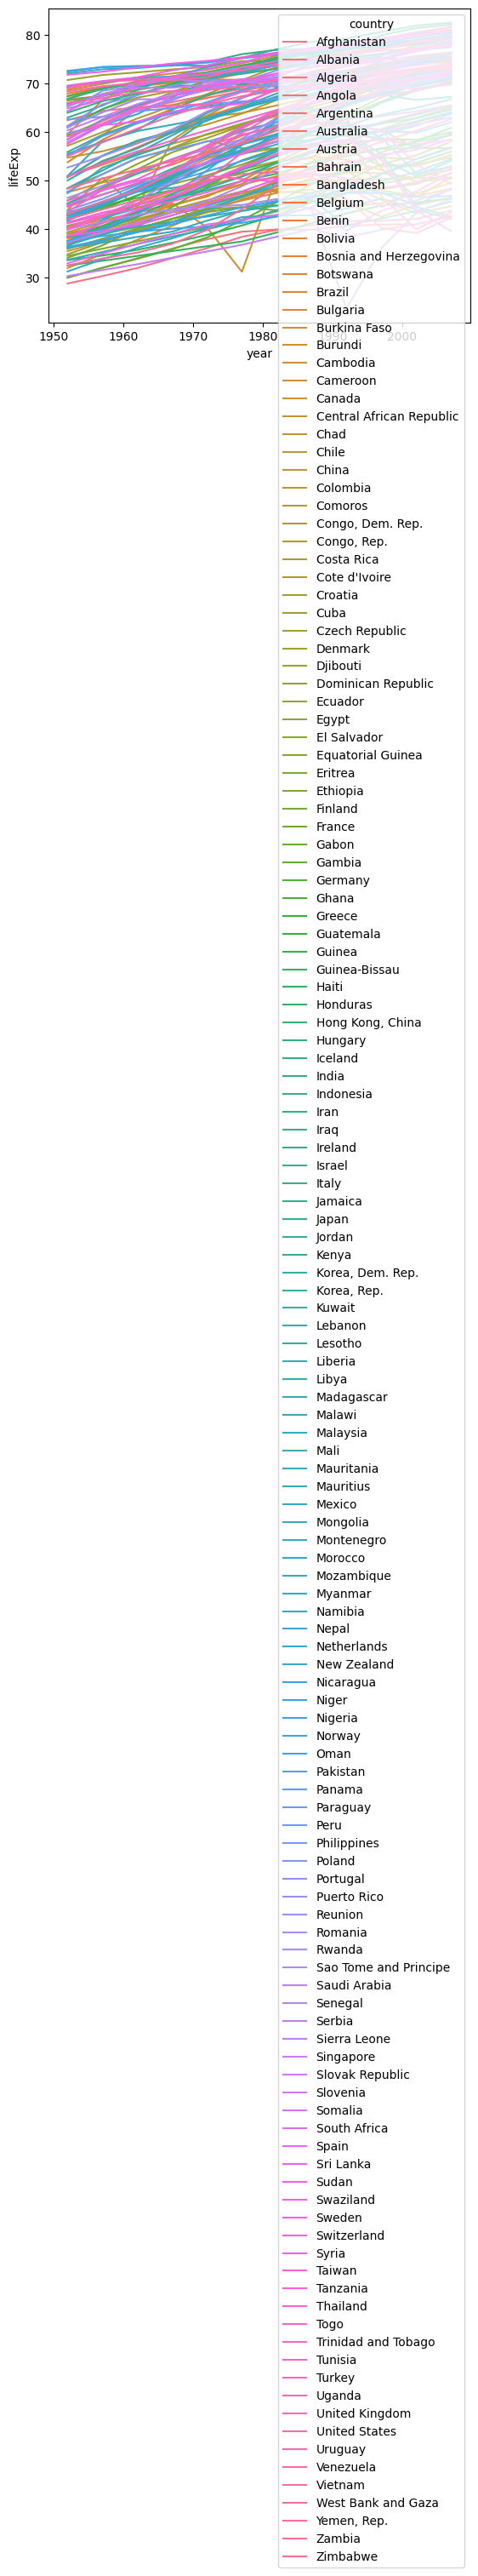

In [30]:
sns.lineplot(data=df, x="year", y="lifeExp", hue="country")

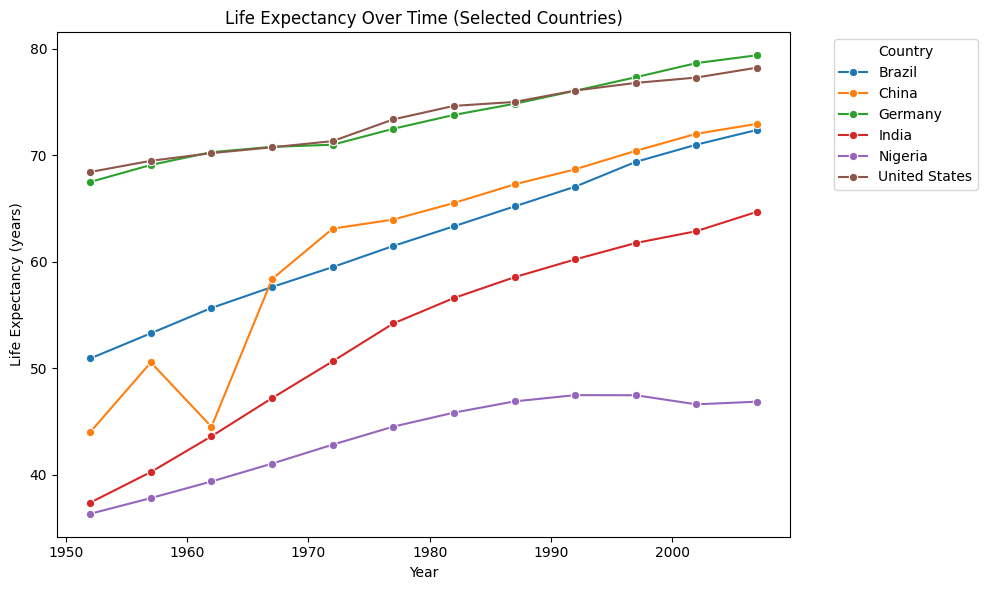

In [31]:
countries = ["India", "China", "United States", "Brazil", "Nigeria", "Germany"]
df_subset = df[df["country"].isin(countries)]

plt.figure(figsize=(10, 6))
sns.lineplot(data=df_subset, x="year", y="lifeExp", hue="country", marker="o")
plt.title("Life Expectancy Over Time (Selected Countries)")
plt.ylabel("Life Expectancy (years)")
plt.xlabel("Year")
plt.legend(title="Country", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()


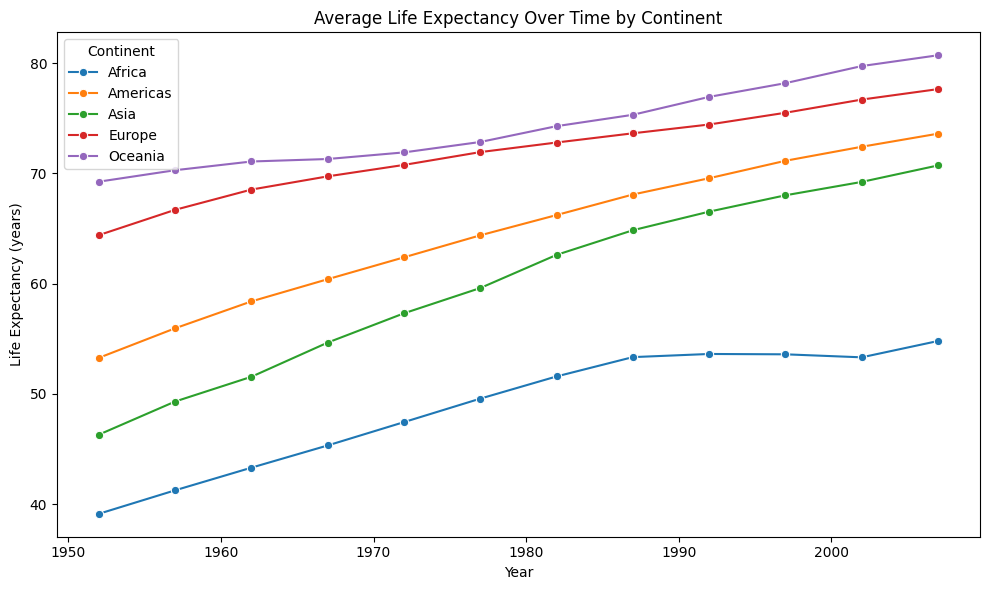

In [32]:
df_cont = (
    df.groupby(["continent", "year"], as_index=False)["lifeExp"].mean()
)

plt.figure(figsize=(10, 6))
sns.lineplot(data=df_cont, x="year", y="lifeExp", hue="continent", marker="o")
plt.title("Average Life Expectancy Over Time by Continent")
plt.ylabel("Life Expectancy (years)")
plt.xlabel("Year")
plt.legend(title="Continent")
plt.tight_layout()


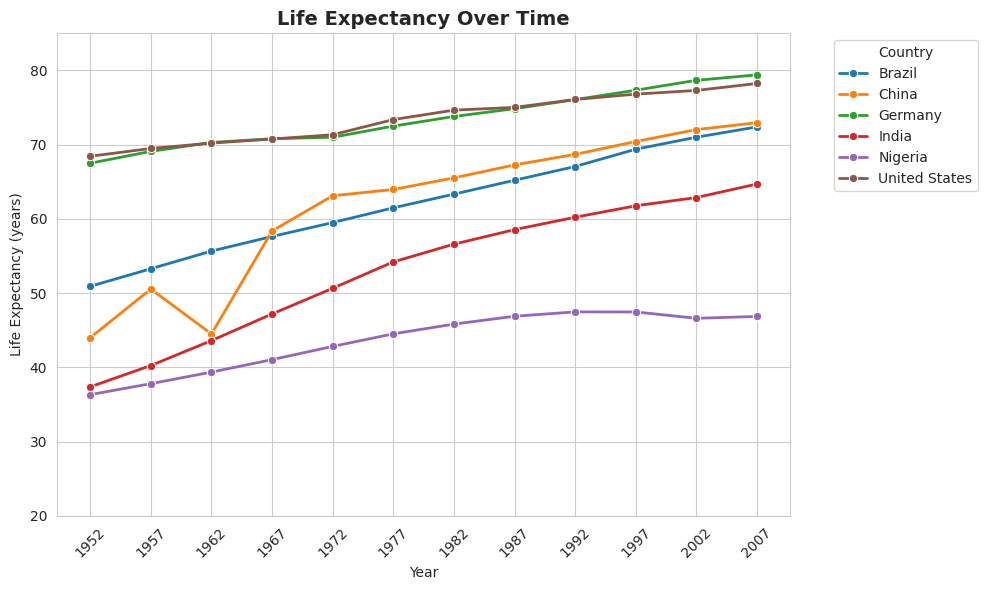

In [33]:
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

sns.lineplot(
    data=df_subset,              # or df_cont
    x="year",
    y="lifeExp",
    hue="country",               # or "continent"
    marker="o",
    linewidth=2,
)

plt.title("Life Expectancy Over Time", fontsize=14, fontweight="bold")
plt.xlabel("Year")
plt.ylabel("Life Expectancy (years)")
plt.xticks(df["year"].unique(), rotation=45)
plt.ylim(20, 85)
plt.legend(title="Country", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()


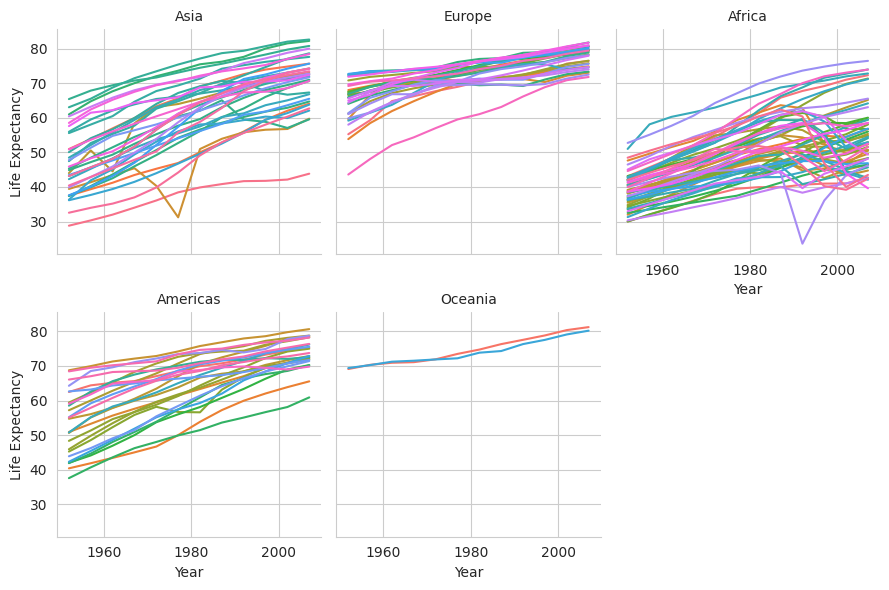

In [34]:
g = sns.relplot(
    data=df,
    x="year",
    y="lifeExp",
    hue="country",
    col="continent",
    kind="line",
    col_wrap=3,
    height=3,
    facet_kws={"sharey": True, "sharex": True},
    legend=False,
)
g.set_titles("{col_name}")
g.set_axis_labels("Year", "Life Expectancy")


<Axes: xlabel='year', ylabel='lifeExp'>

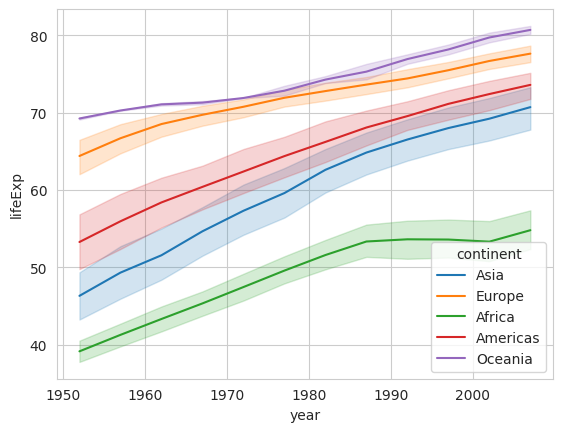

In [35]:
sns.lineplot(data=df, x="year", y="lifeExp", hue="continent")

## Step 14: Conclusions & Class Exercises

### Key Findings
1. **GDP per capita and life expectancy** are positively related — richer countries tend to have longer life expectancy, though the relationship flattens out at higher GDP.
2. **Africa** has the lowest average life expectancy among continents in 2007, while **Oceania/Europe** are the highest.
3. Life expectancy has **increased for almost all countries** between 1952 and 2007.
4. Population size (bubble size in the scatter plot) does not show a strong direct relationship with life expectancy.

### Exercises for Students
1. Filter the dataset to year `1952` and repeat the scatter plot — how different does the world look?
2. Make a **violin plot** of `gdpPercap` by continent (use `plt.yscale("log")`).
3. Use `groupby("continent")["lifeExp"].mean()` to find which continent improved the most from 1952 to 2007.
4. Create a **jointplot** of `gdpPercap` vs `pop` with `kind="hex"`.
5. Pick your own 5 countries and redraw the line plot from Step 13.


In [17]:
# 1. Import all the libraries
# 2. Load your dataset
# 3. Explore the data -> head, info, columns, shape
# 4. Check for missing values and duplicate values
# 5. Univariate Analysis -> When are we are plotting/analysis on one column only.
# 6. Bivariate Analysis -> When are we are plotting/Analyis on two columns.
# 7. Multivariate Analysis -> When are we are plotting/analysis on multiple columns.
# 8. Correlation Heatmap
# 9. Trend Over Time
# 10.Key Findings
